# NSL-KDD Network Intrusion Detection — LWCE Loss Comparison

PyTorch MLP on NSL-KDD (5-class: Normal / DoS / Probe / R2L / U2R).  
Comparing 7 loss functions: `ce`, `wce`, `pwce`, `lwce`, `plwce`, `cb`, `focal`.

In [1]:
# Cell 0: Environment + Setup
!pip install -q torch torchvision optuna pandas openpyxl scikit-learn kagglehub

import os, sys, gc, json, warnings, importlib.util, glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              f1_score)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import GridSampler

warnings.filterwarnings('ignore')

# ── GitHub repo ───────────────────────────────────────────────────
REPO_PATH = '/content/imbalanced-data-LWCE'
if not os.path.exists(REPO_PATH):
    print('Cloning...')
    !git clone https://github.com/gseungho/imbalanced-data-LWCE.git {REPO_PATH}

# ── Load classification loss functions ───────────────────────────
get_clf_loss = None
try:
    spec = importlib.util.spec_from_file_location(
        'clf', f'{REPO_PATH}/image_classification/custom_losses.py'
    )
    clf_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(clf_module)
    get_clf_loss = clf_module.get_clf_loss
    print('✓ Loss functions loaded!')
except Exception as e:
    print(f'Warning: {e}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Constants ─────────────────────────────────────────────────────
DATASET_NAME       = 'NSL-KDD'
NUM_CLASSES        = 5
BATCH_SIZE         = 512
FINAL_EPOCHS       = 50
PROXY_EPOCHS       = 10
PROXY_SUBSET_RATIO = 0.20
RESULTS_DIR = '/content/gdrive/MyDrive/imbalanced-data-LWCE/network_data/results/NSL-KDD'
os.makedirs(RESULTS_DIR, exist_ok=True)

CLASS_NAMES = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

# NSL-KDD 41개 피처명 (파일에 헤더 없음)
KDD_COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

# 39가지 공격 타입 → 5-class 매핑
DOS_ATTACKS   = {'back','land','neptune','pod','smurf','teardrop',
                 'apache2','udpstorm','processtable','worm'}
PROBE_ATTACKS = {'satan','ipsweep','nmap','portsweep','mscan','saint'}
R2L_ATTACKS   = {'guess_passwd','ftp_write','imap','phf','multihop',
                 'warezmaster','warezclient','spy','xlock','xsnoop',
                 'snmpguess','snmpgetattack','httptunnel','sendmail','named'}
U2R_ATTACKS   = {'buffer_overflow','loadmodule','perl','rootkit',
                 'xterm','ps','sqlattack'}

def map_label(lbl):
    lbl = str(lbl).strip().lower()
    if lbl == 'normal':           return 0
    if lbl in DOS_ATTACKS:        return 1
    if lbl in PROBE_ATTACKS:      return 2
    if lbl in R2L_ATTACKS:        return 3
    if lbl in U2R_ATTACKS:        return 4
    return 1  # 미분류 공격 → DoS로 처리

print(f'Results dir: {RESULTS_DIR}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.8 MB/s eta 0:00:00
Cloning...
Cloning into '/content/imbalanced-data-LWCE'...
remote: Enumerating objects: 631, done.
remote: Counting objects: 100% (631/631), done.
remote: Compressing objects: 100% (459/459), done.
remote: Total 631 (delta 251), reused 447 (delta 148), pack-reused 0 (from 0)
Receiving objects: 100% (631/631), 33.83 MiB | 15.30 MiB/s, done.
Resolving deltas: 100% (251/251), done.
✓ Loss functions loaded!
Device: cuda
Results dir: /content/gdrive/MyDrive/imbalanced-data-LWCE/network_data/results/NSL-KDD


In [2]:
# Cell 1: Load & Preprocess NSL-KDD
import kagglehub

def load_nslkdd():
    print('Downloading NSL-KDD...')
    path = kagglehub.dataset_download('hassan06/nslkdd')
    print(f'Dataset path: {path}')

    files = glob.glob(f'{path}/**/*', recursive=True)
    # KDDTrain+.txt 만 선택 (KDDTrain+_20Percent.txt 제외)
    train_file = next(f for f in files
                      if os.path.basename(f) == 'KDDTrain+.txt')
    test_file  = next(f for f in files
                      if os.path.basename(f) == 'KDDTest+.txt')
    print(f'Train: {train_file}')
    print(f'Test:  {test_file}')

    df_train = pd.read_csv(train_file, names=KDD_COLUMNS, header=None)
    df_test  = pd.read_csv(test_file,  names=KDD_COLUMNS, header=None)

    df_train['class'] = df_train['label'].apply(map_label)
    df_test['class']  = df_test['label'].apply(map_label)

    # 범주형 3개 → one-hot (train+test 합쳐서 인코딩해야 일관성 보장)
    cat_cols = ['protocol_type', 'service', 'flag']
    df_all = pd.concat([df_train, df_test], axis=0, ignore_index=True)
    df_all = pd.get_dummies(df_all, columns=cat_cols, dtype=np.float32)
    n_train = len(df_train)
    df_train_enc = df_all.iloc[:n_train].copy()
    df_test_enc  = df_all.iloc[n_train:].copy()

    feature_cols = [c for c in df_train_enc.columns
                    if c not in ('label', 'difficulty', 'class')]

    X_tr = df_train_enc[feature_cols].values.astype(np.float32)
    y_tr = df_train_enc['class'].values.astype(np.int64)
    X_te = df_test_enc[feature_cols].values.astype(np.float32)
    y_te = df_test_enc['class'].values.astype(np.int64)

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_te)

    # Train → Train / Val split (85:15 stratified)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr, y_tr, test_size=0.15, stratify=y_tr, random_state=42
    )

    input_dim    = X_tr.shape[1]
    class_counts = [int((y_tr == i).sum()) for i in range(NUM_CLASSES)]

    print(f'\n✓ Loaded: Train={len(X_tr):,}, Val={len(X_val):,}, Test={len(X_te):,}')
    print(f'Input dim: {input_dim}')
    print('\nClass distribution (train):')
    for i, (name, cnt) in enumerate(zip(CLASS_NAMES, class_counts)):
        pct = cnt / sum(class_counts) * 100
        print(f'  {i} {name:8s}: {cnt:6,d} ({pct:.2f}%)')
    ir = max(class_counts) / max(min(c for c in class_counts if c > 0), 1)
    print(f'Imbalance ratio: {ir:.0f}:1')

    return X_tr, X_val, X_te, y_tr, y_val, y_te, class_counts, input_dim

def make_loaders(X_tr, X_val, X_te, y_tr, y_val, y_te, batch_size):
    def ds(X, y):
        return TensorDataset(torch.tensor(X, dtype=torch.float32),
                             torch.tensor(y, dtype=torch.long))
    train_loader = DataLoader(ds(X_tr,  y_tr),  batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(ds(X_val, y_val), batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(ds(X_te,  y_te),  batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

X_tr, X_val, X_te, y_tr, y_val, y_te, class_counts, INPUT_DIM = load_nslkdd()
train_loader, val_loader, test_loader = make_loaders(
    X_tr, X_val, X_te, y_tr, y_val, y_te, BATCH_SIZE
)

Using Colab cache for faster access to the 'nslkdd' dataset.
Dataset path: /kaggle/input/nslkdd
Train: /kaggle/input/nslkdd/KDDTrain+.txt
Test:  /kaggle/input/nslkdd/KDDTest+.txt

✓ Loaded: Train=107,077, Val=18,896, Test=22,544
Input dim: 122

Class distribution (train):
  0 Normal  : 57,241 (53.46%)
  1 DoS     : 39,038 (36.46%)
  2 Probe   :  9,908 (9.25%)
  3 R2L     :    846 (0.79%)
  4 U2R     :     44 (0.04%)
Imbalance ratio: 1301:1


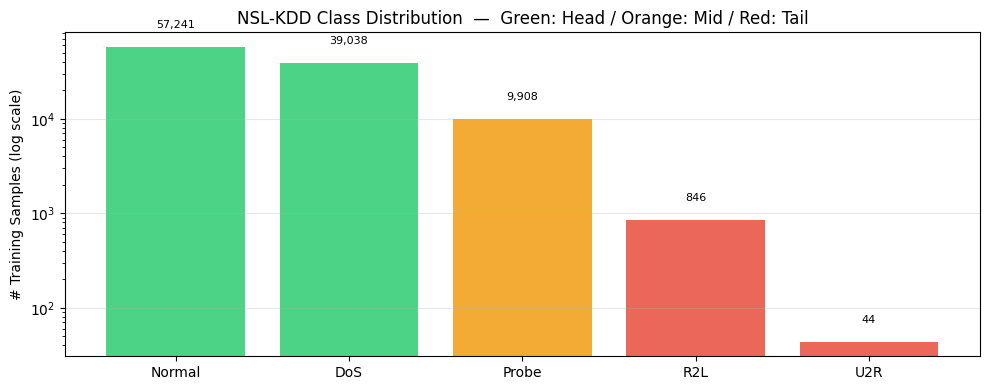

Head (≥28551): 2 classes
Mid  (3746–28551): 1 classes
Tail (<3746): 2 classes


In [3]:
# Cell 2: Class Distribution Visualization
def visualize_distribution(class_counts, class_names, title, save_path):
    counts = np.array(class_counts)
    order  = np.argsort(counts)[::-1]
    q1, q3 = np.percentile(counts, [33, 66])
    colors = ['#2ecc71' if c >= q3 else '#f39c12' if c >= q1 else '#e74c3c'
              for c in counts[order]]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(class_names)), counts[order], color=colors, alpha=0.85)
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels([class_names[i] for i in order], fontsize=10)
    ax.set_yscale('log')
    ax.set_ylabel('# Training Samples (log scale)')
    ax.set_title(f'{title}  —  Green: Head / Orange: Mid / Red: Tail')
    ax.grid(True, alpha=0.3, axis='y')
    for i, c in enumerate(counts[order]):
        ax.text(i, c * 1.5, f'{c:,}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

    q1_val, q3_val = np.percentile(counts, [33, 66])
    head = sum(1 for c in counts if c >= q3_val)
    mid  = sum(1 for c in counts if q1_val <= c < q3_val)
    tail = sum(1 for c in counts if c < q1_val)
    print(f'Head (≥{q3_val:.0f}): {head} classes')
    print(f'Mid  ({q1_val:.0f}–{q3_val:.0f}): {mid} classes')
    print(f'Tail (<{q1_val:.0f}): {tail} classes')

visualize_distribution(
    class_counts, CLASS_NAMES,
    'NSL-KDD Class Distribution',
    f'{RESULTS_DIR}/class_distribution.png'
)

In [4]:
# Cell 3: MLP Model + Evaluation Functions

class MLP(nn.Module):
    """3-hidden-layer MLP with BatchNorm + Dropout."""
    def __init__(self, input_dim, num_classes,
                 hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def build_mlp():
    return MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)


def compute_metrics(model, loader, class_counts):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            preds = model(X_b.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_b.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    per_f1 = f1_score(y_true, y_pred, average=None,
                      labels=list(range(NUM_CLASSES)), zero_division=0)

    counts = np.array(class_counts)
    q1, q3 = np.percentile(counts, [33, 66])
    head_idx = [i for i in range(NUM_CLASSES) if counts[i] >= q3]
    mid_idx  = [i for i in range(NUM_CLASSES) if q1 <= counts[i] < q3]
    tail_idx = [i for i in range(NUM_CLASSES) if counts[i] < q1]

    return {
        'Accuracy':          float(accuracy_score(y_true, y_pred)),
        'Balanced_Accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'F1_Macro':          float(f1_score(y_true, y_pred, average='macro',    zero_division=0)),
        'F1_Weighted':       float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'Per_Class_F1':      per_f1.tolist(),
        'Head_F1': float(per_f1[head_idx].mean()) if head_idx else 0.0,
        'Mid_F1':  float(per_f1[mid_idx].mean())  if mid_idx  else 0.0,
        'Tail_F1': float(per_f1[tail_idx].mean()) if tail_idx else 0.0,
    }

print('✓ MLP and evaluation functions defined')

✓ MLP and evaluation functions defined


In [5]:
# Cell 4: train_model() — definition only, not executed here

def train_model(loss_name, class_counts, tr_loader, val_loader,
                alpha=1.0, gamma=2.0, epochs=FINAL_EPOCHS):
    """
    Args:
        tr_loader: 훈련 DataLoader (proxy 시 subset loader 전달)
    Returns:
        (model, history, best_F1_Macro)
    """
    model = build_mlp()

    if get_clf_loss is not None:
        criterion = get_clf_loss(loss_name, class_counts, alpha=alpha, gamma=gamma)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=5, factor=0.5, min_lr=1e-6
    )

    history      = {'train_loss': [], 'val_F1_Macro': []}
    best_F1_Macro = 0.0
    best_state   = None

    print(f"\n{'='*50}\nTraining {loss_name.upper()} "
          f"(α={alpha:.2f}, γ={gamma:.2f})\n{'='*50}")

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            logits   = model(X_b)
            loss     = criterion(logits, y_b)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1

        avg_loss = epoch_loss / max(n_batches, 1)
        history['train_loss'].append(avg_loss)

        # 매 에폭 검증 (tabular → 빠름)
        metrics  = compute_metrics(model, val_loader, class_counts)
        bal_acc  = metrics['F1_Macro']
        history['val_F1_Macro'].append(bal_acc)
        scheduler.step(bal_acc)

        if bal_acc > best_F1_Macro:
            best_F1_Macro = bal_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | '
                  f'BalAcc: {bal_acc:.4f}')

    if best_state is not None:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    print(f'✓ {loss_name.upper()} best F1-Macro: {best_F1_Macro:.4f}')
    return model, history, best_F1_Macro

print('✓ train_model defined (not executed yet)')

✓ train_model defined (not executed yet)


In [6]:
# Cell 5: Optuna Hyperparameter Search
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ['TQDM_DISABLE'] = '1'

def _make_proxy_loader(ratio=PROXY_SUBSET_RATIO):
    n   = int(len(train_loader.dataset) * ratio)
    idx = np.random.choice(len(train_loader.dataset), n, replace=False)
    return DataLoader(Subset(train_loader.dataset, idx),
                     batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

def _cleanup(model=None):
    if model is not None:
        del model
    gc.collect()
    torch.cuda.empty_cache()

print(f'Optuna search (proxy: {PROXY_EPOCHS} epochs, {PROXY_SUBSET_RATIO*100:.0f}% subset)\n')
optuna_best = {}
proxy_loader = _make_proxy_loader()

# ── PWCE: alpha [0.5, 5.0] ────────────────────────────────────────
N_PWCE = 20
study_pwce = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'alpha': np.linspace(0.5, 5.0, N_PWCE).tolist()})
)
def obj_pwce(trial):
    alpha = trial.suggest_float('alpha', 0.5, 5.0)
    model, _, score = train_model('pwce', class_counts, proxy_loader, val_loader,
                                  alpha=alpha, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_pwce.optimize(obj_pwce, n_trials=N_PWCE)
best_pwce = study_pwce.best_params
optuna_best['pwce'] = best_pwce
print(f'✓ PWCE  best: alpha={best_pwce["alpha"]:.2f}  (BalAcc={study_pwce.best_value:.4f})')

# ── PLWCE: alpha [1.0, 10.0] ─────────────────────────────────────
N_PLWCE = 20
study_plwce = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'alpha': np.linspace(1.0, 10.0, N_PLWCE).tolist()})
)
def obj_plwce(trial):
    alpha = trial.suggest_float('alpha', 1.0, 10.0)
    model, _, score = train_model('plwce', class_counts, proxy_loader, val_loader,
                                  alpha=alpha, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_plwce.optimize(obj_plwce, n_trials=N_PLWCE)
best_plwce = study_plwce.best_params
optuna_best['plwce'] = best_plwce
print(f'✓ PLWCE best: alpha={best_plwce["alpha"]:.2f}  (BalAcc={study_plwce.best_value:.4f})')

# ── FOCAL: gamma [0.5, 5.0] ──────────────────────────────────────
N_FOCAL = 20
study_focal = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'gamma': np.linspace(0.5, 5.0, N_FOCAL).tolist()})
)
def obj_focal(trial):
    gamma = trial.suggest_float('gamma', 0.5, 5.0)
    model, _, score = train_model('focal', class_counts, proxy_loader, val_loader,
                                  gamma=gamma, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_focal.optimize(obj_focal, n_trials=N_FOCAL)
best_focal = study_focal.best_params
optuna_best['focal'] = best_focal
print(f'✓ FOCAL best: gamma={best_focal["gamma"]:.2f}  (BalAcc={study_focal.best_value:.4f})')

print(f'\nOptuna Results:\n{json.dumps(optuna_best, indent=2)}')

Optuna search (proxy: 10 epochs, 20% subset)


Training PWCE (α=4.76, γ=2.00)
Epoch 10/10 | Loss: 0.4112 | BalAcc: 0.1206
✓ PWCE best F1-Macro: 0.1395

Training PWCE (α=0.74, γ=2.00)
Epoch 10/10 | Loss: 0.1265 | BalAcc: 0.7665
✓ PWCE best F1-Macro: 0.8250

Training PWCE (α=5.00, γ=2.00)
Epoch 10/10 | Loss: 0.4043 | BalAcc: 0.2091
✓ PWCE best F1-Macro: 0.2091

Training PWCE (α=2.39, γ=2.00)
Epoch 10/10 | Loss: 0.2813 | BalAcc: 0.5739
✓ PWCE best F1-Macro: 0.5739

Training PWCE (α=2.87, γ=2.00)
Epoch 10/10 | Loss: 0.3568 | BalAcc: 0.3615
✓ PWCE best F1-Macro: 0.3615

Training PWCE (α=4.53, γ=2.00)
Epoch 10/10 | Loss: 0.3747 | BalAcc: 0.1472
✓ PWCE best F1-Macro: 0.1498

Training PWCE (α=1.92, γ=2.00)
Epoch 10/10 | Loss: 0.3888 | BalAcc: 0.6011
✓ PWCE best F1-Macro: 0.6137

Training PWCE (α=3.58, γ=2.00)
Epoch 10/10 | Loss: 0.3230 | BalAcc: 0.1371
✓ PWCE best F1-Macro: 0.1951

Training PWCE (α=1.45, γ=2.00)
Epoch 10/10 | Loss: 0.4166 | BalAcc: 0.6772
✓ PWCE best F1-Macro: 0.7098

Training

In [7]:
# Cell 6: Full Experiment (N_SEEDS seeds)
import random

N_SEEDS       = 5
LOSS_CONFIGS  = ['ce', 'wce', 'pwce', 'lwce', 'plwce', 'cb', 'focal']
seed_results   = {ln: [] for ln in LOSS_CONFIGS}
seed_histories = {ln: [] for ln in LOSS_CONFIGS}

print(f"\n{'='*60}")
print(f'FULL EXPERIMENT: {FINAL_EPOCHS} epochs × {len(LOSS_CONFIGS)} losses × {N_SEEDS} seeds')
print(f"{'='*60}")

for seed in range(N_SEEDS):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print(f"\n{'─'*25}  Seed {seed}  {'─'*25}")

    for loss_name in LOSS_CONFIGS:
        alpha = optuna_best.get(loss_name, {}).get('alpha', 1.0)
        gamma = optuna_best.get('focal', {}).get('gamma', 2.0) if loss_name == 'focal' else 2.0

        model, history, _ = train_model(
            loss_name, class_counts, train_loader, val_loader,
            alpha=alpha, gamma=gamma, epochs=FINAL_EPOCHS
        )
        metrics = compute_metrics(model, test_loader, class_counts)
        seed_results[loss_name].append(metrics)
        seed_histories[loss_name].append(history)
        _cleanup(model)

print(f"\n{'='*60}")
print('✓ Full experiment completed!')
print(f"{'='*60}")


FULL EXPERIMENT: 50 epochs × 7 losses × 5 seeds

─────────────────────────  Seed 0  ─────────────────────────

Training CE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 0.0221 | BalAcc: 0.7675
Epoch 20/50 | Loss: 0.0170 | BalAcc: 0.9143
Epoch 30/50 | Loss: 0.0158 | BalAcc: 0.8935
Epoch 40/50 | Loss: 0.0147 | BalAcc: 0.9378
Epoch 50/50 | Loss: 0.0101 | BalAcc: 0.9370
✓ CE best F1-Macro: 0.9406

Training WCE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 0.1784 | BalAcc: 0.8026
Epoch 20/50 | Loss: 0.1151 | BalAcc: 0.8000
Epoch 30/50 | Loss: 0.1083 | BalAcc: 0.8175
Epoch 40/50 | Loss: 0.0803 | BalAcc: 0.8432
Epoch 50/50 | Loss: 0.0929 | BalAcc: 0.8575
✓ WCE best F1-Macro: 0.8756

Training PWCE (α=0.50, γ=2.00)
Epoch 10/50 | Loss: 0.0503 | BalAcc: 0.8724
Epoch 20/50 | Loss: 0.0385 | BalAcc: 0.8967
Epoch 30/50 | Loss: 0.0297 | BalAcc: 0.8887
Epoch 40/50 | Loss: 0.0251 | BalAcc: 0.8906
Epoch 50/50 | Loss: 0.0207 | BalAcc: 0.8956
✓ PWCE best F1-Macro: 0.9160

Training LWCE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 


EXPERIMENT SUMMARY (mean ± std, N=5)
Loss                Bal_Acc           F1_Macro            Head_F1            Tail_F1
ce            0.5688±0.0169      0.5987±0.0204      0.8489±0.0043      0.2693±0.0538
wce           0.6205±0.0083      0.5840±0.0201      0.8552±0.0021      0.2201±0.0463
pwce          0.6152±0.0140      0.5891±0.0142      0.8540±0.0079      0.2409±0.0309
lwce          0.6008±0.0037      0.6349±0.0028      0.8505±0.0021      0.3513±0.0080
plwce         0.6081±0.0090      0.6376±0.0098      0.8522±0.0039      0.3649±0.0098
cb            0.6201±0.0074      0.5953±0.0141      0.8523±0.0024      0.2506±0.0366
focal         0.5733±0.0072      0.6073±0.0082      0.8459±0.0016      0.2908±0.0191


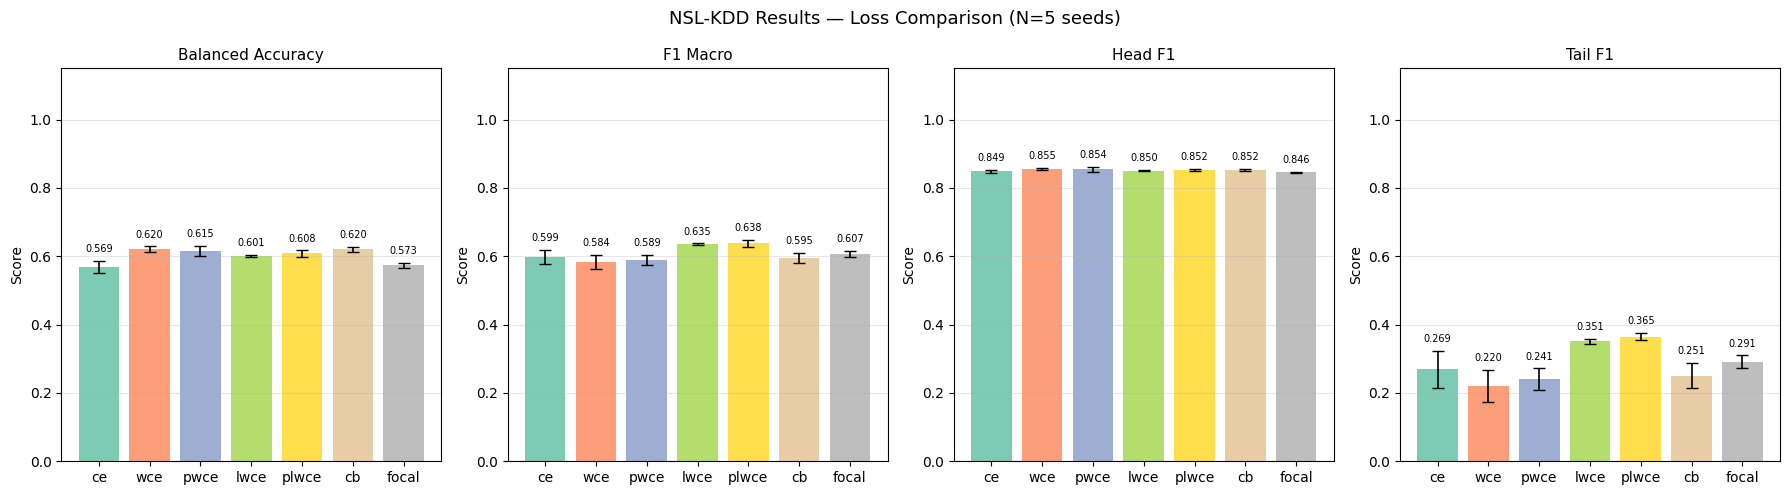

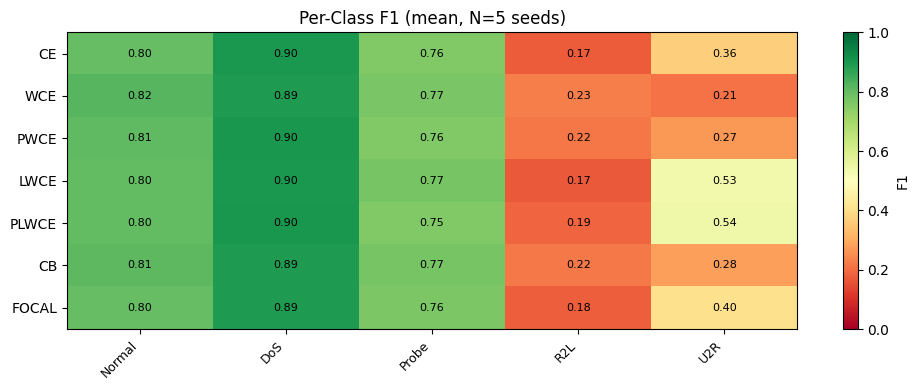

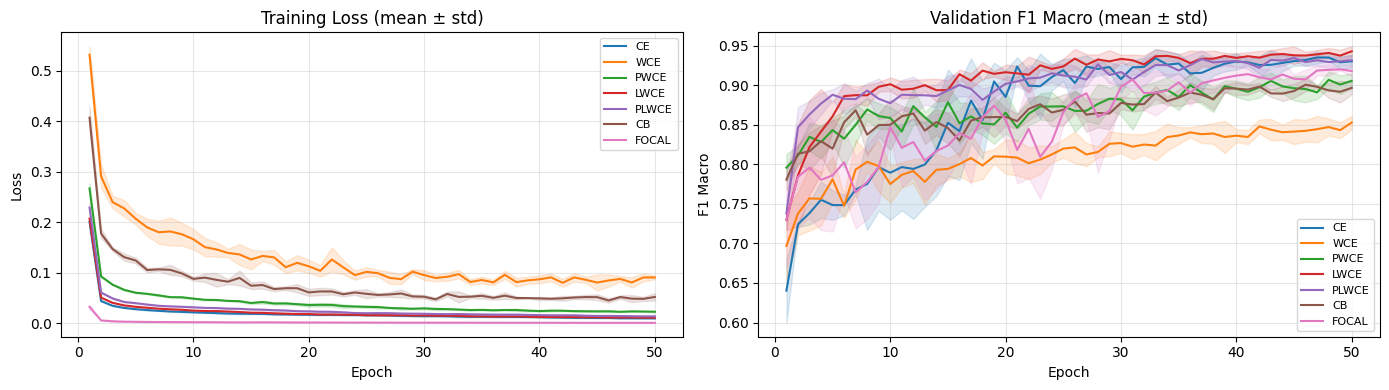

✓ Saved JSON
✓ Saved Excel

FINAL SUMMARY (mean ± std, N=5)
 Loss Balanced_Accuracy      F1_Macro       Head_F1       Tail_F1
   ce     0.5688±0.0169 0.5987±0.0204 0.8489±0.0043 0.2693±0.0538
  wce     0.6205±0.0083 0.5840±0.0201 0.8552±0.0021 0.2201±0.0463
 pwce     0.6152±0.0140 0.5891±0.0142 0.8540±0.0079 0.2409±0.0309
 lwce     0.6008±0.0037 0.6349±0.0028 0.8505±0.0021 0.3513±0.0080
plwce     0.6081±0.0090 0.6376±0.0098 0.8522±0.0039 0.3649±0.0098
   cb     0.6201±0.0074 0.5953±0.0141 0.8523±0.0024 0.2506±0.0366
focal     0.5733±0.0072 0.6073±0.0082 0.8459±0.0016 0.2908±0.0191


In [8]:
# Cell 7: Aggregate + Visualize + Save Results
METRIC_KEYS = ['Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Mid_F1', 'Tail_F1', 'Accuracy', 'F1_Weighted']
loss_names  = LOSS_CONFIGS

# ── Aggregate mean ± std ──────────────────────────────────────────
agg = {}
for ln in loss_names:
    agg[ln] = {}
    for k in METRIC_KEYS:
        vals = [r[k] for r in seed_results[ln]]
        agg[ln][k] = {'mean': float(np.mean(vals)), 'std': float(np.std(vals))}
    per_cls_all = np.array([r['Per_Class_F1'] for r in seed_results[ln]])
    agg[ln]['Per_Class_F1_mean'] = per_cls_all.mean(axis=0).tolist()
    agg[ln]['Per_Class_F1_std']  = per_cls_all.std(axis=0).tolist()

# ── Summary print ─────────────────────────────────────────────────
def ms(ln, k): return f"{agg[ln][k]['mean']:.4f}±{agg[ln][k]['std']:.4f}"

print(f"\n{'='*60}\nEXPERIMENT SUMMARY (mean ± std, N={N_SEEDS})\n{'='*60}")
W = 17
print(f"{'Loss':8s}  {'Bal_Acc':>{W}}  {'F1_Macro':>{W}}  {'Head_F1':>{W}}  {'Tail_F1':>{W}}")
for ln in loss_names:
    print(f"{ln:8s}  {ms(ln,'Balanced_Accuracy'):>{W}}  {ms(ln,'F1_Macro'):>{W}}  {ms(ln,'Head_F1'):>{W}}  {ms(ln,'Tail_F1'):>{W}}")

# ── Bar chart with error bars ─────────────────────────────────────
colors = plt.cm.Set2(np.linspace(0, 1, len(loss_names)))
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'{DATASET_NAME} Results — Loss Comparison (N={N_SEEDS} seeds)', fontsize=13)
for ax, key, title in zip(
    axes,
    ['Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Tail_F1'],
    ['Balanced Accuracy',  'F1 Macro', 'Head F1', 'Tail F1']
):
    means = [agg[ln][key]['mean'] for ln in loss_names]
    stds  = [agg[ln][key]['std']  for ln in loss_names]
    bars  = ax.bar(loss_names, means, color=colors, alpha=0.85)
    ax.errorbar(loss_names, means, yerr=stds,
                fmt='none', color='black', capsize=4, linewidth=1.2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.15)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.02,
                f'{m:.3f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class F1 heatmap (mean over seeds) ────────────────────────
per_cls_mat = np.array([agg[ln]['Per_Class_F1_mean'] for ln in loss_names])
fig, ax = plt.subplots(figsize=(max(10, NUM_CLASSES), 4))
im = ax.imshow(per_cls_mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(loss_names)))
ax.set_yticklabels([ln.upper() for ln in loss_names])
ax.set_title(f'Per-Class F1 (mean, N={N_SEEDS} seeds)')
plt.colorbar(im, ax=ax, label='F1')
for i in range(len(loss_names)):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f'{per_cls_mat[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Training curves (mean ± std band) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_x = np.arange(1, FINAL_EPOCHS + 1)
for ln in loss_names:
    loss_arr = np.array([h['train_loss']   for h in seed_histories[ln]])
    f1_arr   = np.array([h['val_F1_Macro'] for h in seed_histories[ln]])
    for ax, arr in zip(axes, [loss_arr, f1_arr]):
        m, s = arr.mean(axis=0), arr.std(axis=0)
        line, = ax.plot(epochs_x, m, label=ln.upper())
        ax.fill_between(epochs_x, m - s, m + s, alpha=0.15, color=line.get_color())
for ax, title, ylabel in zip(axes,
    ['Training Loss (mean ± std)', 'Validation F1 Macro (mean ± std)'],
    ['Loss', 'F1 Macro']):
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save JSON ─────────────────────────────────────────────────────
fname = DATASET_NAME.lower().replace('-', '').replace(' ', '_')
results_json = {
    'metadata': {
        'dataset':      DATASET_NAME,
        'model':        'MLP (256-128-64, BatchNorm, Dropout=0.3)',
        'num_classes':  NUM_CLASSES,
        'class_names':  CLASS_NAMES,
        'final_epochs': FINAL_EPOCHS,
        'batch_size':   BATCH_SIZE,
        'n_seeds':      N_SEEDS,
        'optuna_best':  optuna_best,
        'class_counts': class_counts,
    },
    'aggregated': agg,
    'per_seed':   {ln: seed_results[ln] for ln in loss_names},
}
with open(f'{RESULTS_DIR}/{fname}_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)
print('✓ Saved JSON')

# ── Save Excel ────────────────────────────────────────────────────
summary_rows = []
for ln in loss_names:
    row = {'Loss': ln}
    for k in METRIC_KEYS:
        row[f'{k}_mean'] = round(agg[ln][k]['mean'], 4)
        row[f'{k}_std']  = round(agg[ln][k]['std'],  4)
        row[k]           = f"{agg[ln][k]['mean']:.4f}±{agg[ln][k]['std']:.4f}"
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)

per_class_df = pd.DataFrame(
    {ln: agg[ln]['Per_Class_F1_mean'] for ln in loss_names},
    index=CLASS_NAMES
)

raw_rows = []
for ln in loss_names:
    for s, r in enumerate(seed_results[ln]):
        row = {'loss': ln, 'seed': s}
        for k in METRIC_KEYS:
            row[k] = r[k]
        raw_rows.append(row)

with pd.ExcelWriter(f'{RESULTS_DIR}/{fname}_results.xlsx', engine='openpyxl') as writer:
    summary_df.to_excel(writer,   sheet_name='Summary_MeanStd',  index=False)
    per_class_df.to_excel(writer, sheet_name='Per_Class_F1_Mean')
    pd.DataFrame(raw_rows).to_excel(writer, sheet_name='Per_Seed_Raw', index=False)
print('✓ Saved Excel')

print(f"\n{'='*60}\nFINAL SUMMARY (mean ± std, N={N_SEEDS})\n{'='*60}")
disp = ['Loss', 'Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Tail_F1']
print(summary_df[disp].to_string(index=False))